Jalur Python: c:\Users\Lenovo\anaconda3\envs\metodepotensial\python.exe
✅ SEMUA LIBRARY TERDETEKSI: xarray, harmonica, pyproj, verde siap digunakan.


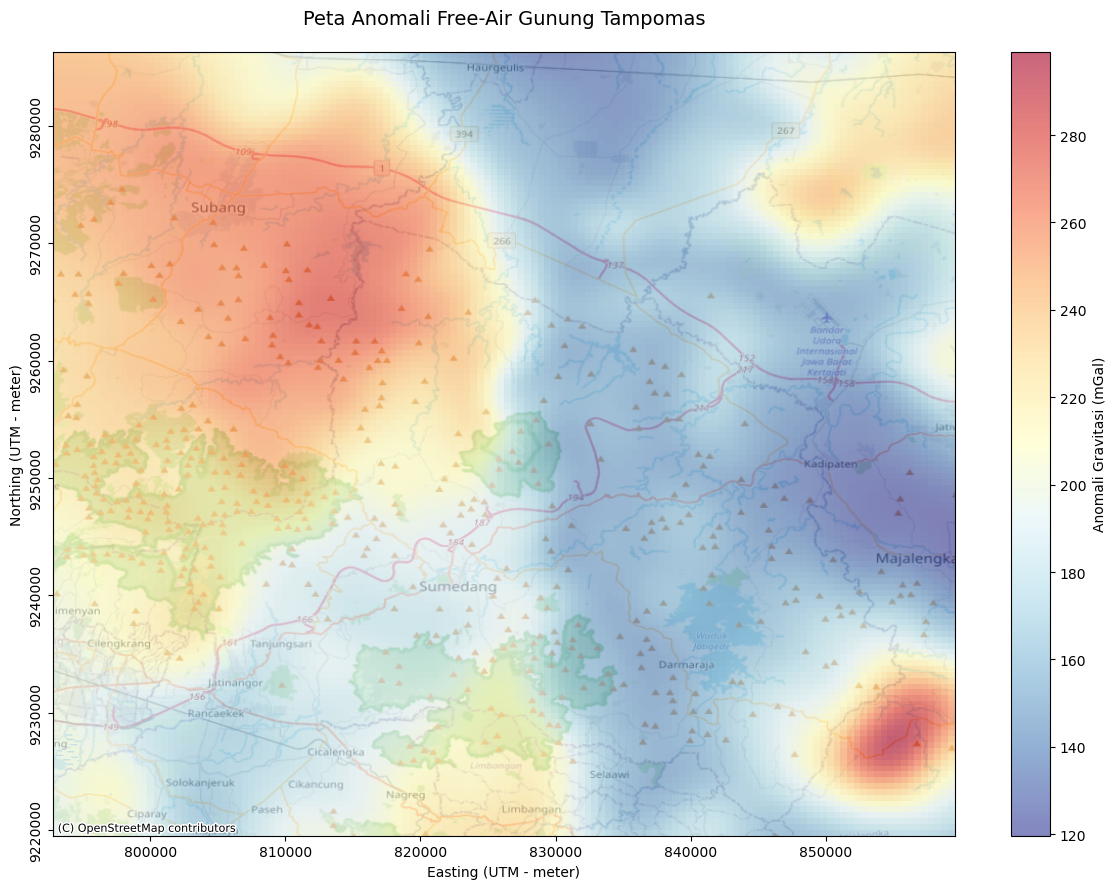

In [ ]:
import sys
import os

# Menampilkan jalur Python yang sedang digunakan oleh VS Code saat ini
print(f"Jalur Python: {sys.executable}")

try:
    import xarray as xr
    import harmonica as hm
    import pyproj
    import verde as vd
    print("✅ SEMUA LIBRARY TERDETEKSI: xarray, harmonica, pyproj, verde siap digunakan.")
except ImportError as e:
    print(f"❌ ERROR: {e}")
    print("Sedang mencoba sinkronisasi paksa...")
    # Perintah di bawah ini akan menginstal langsung ke jalur yang digunakan Notebook
    !{sys.executable} -m pip install xarray harmonica pyproj verde contextily

import xarray as xr
import matplotlib.pyplot as plt
import contextily as cx
import os

# 1. Pastikan Path Benar
path_file = "../data/proses/grid_tampomas_fa.nc"

if not os.path.exists(path_file):
    print(f"❌ File TIDAK DITEMUKAN!")
else:
    grid = xr.open_dataset(path_file)
    var_name = list(grid.data_vars)[0]

    # 2. Plotting
    fig, ax = plt.subplots(figsize=(12, 9))
    
    # Plot data gravitasi dengan label satuan mGal pada colorbar
    # im = plot xarray
    im = grid[var_name].plot(
        ax=ax, 
        cmap="RdYlBu_r", 
        alpha=0.6, 
        add_colorbar=True,
        cbar_kwargs={'label': 'Anomali Gravitasi (mGal)'} # Menambahkan satuan mGal
    )
    
    # 3. MENGATUR FORMAT ANGKA KOORDINAT (Plain / Bukan 1e6)
    ax.ticklabel_format(useOffset=False, style='plain')
    
    # 4. MENGATUR POSISI VERTIKAL PADA NORTHING
    # rotation=90 membuat angka berdiri tegak (vertikal)
    plt.yticks(rotation=90, va='center')

    # 5. Tambahkan Basemap (Satelit/OpenStreetMap)
    try:
        # Menggunakan EPSG:32748 (WGS 84 / UTM zone 48S) sesuai lokasi Jawa Barat
        cx.add_basemap(ax, crs="EPSG:32748", source=cx.providers.OpenStreetMap.Mapnik)
    except Exception as e:
        print(f"Gagal memuat basemap: {e}")

    # Labeling yang informatif
    plt.title("Peta Anomali Free-Air Gunung Tampomas", fontsize=14, pad=20)
    plt.xlabel("Easting (UTM - meter)", fontsize=10)
    plt.ylabel("Northing (UTM - meter)", fontsize=10)
    
    plt.tight_layout()
    plt.show()